In [3]:
import os, glob, re, random
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive
import pandas as pd
drive.mount('/content/drive')

# --- image processing ---
import cv2

# ========== Settings ==========
IMG_GLOB = "/content/drive/MyDrive/DATA/*.png" # Updated path to Google Drive
OUT_SIZE = 28
TRAIN_RATIO = 0.7
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

# ========== Helper: label mapping from SnapN.png ==========
def label_from_filename(path: str) -> int:
    """
    10-19   -> 1
    20-29  -> 2
    ...
    90-99 -> 9
    00-09 -> 0
    """
    base = os.path.basename(path)
    # Updated regex to match NN.png format (e.g., 00.png, 15.png)
    m = re.search(r"(\d{2})\.png$", base, re.IGNORECASE)
    if not m:
        # Updated error message to reflect the new expected format
        raise ValueError(f"檔名不符合 NN.png 格式: {base}")
    n = int(m.group(1)) # Extract the two-digit number

    # Implement the new mapping logic
    # The tens digit of n directly gives the label (00-09 -> 0, 10-19 -> 1, etc.)
    label = n // 10
    return label

# ========== Helper: preprocess to MNIST-like (28x28, white digit on black background) ==========
def preprocess_mnist_like(img_bgr: np.ndarray, out_size: int = 28) -> np.ndarray:
		## img_bgr → 輸入圖片 : np.ndarray → 型別是 NumPy array
               ## -> np.ndarray:  這個函式會回傳 numpy array
    """
    Steps:
    1) grayscale
    2) denoise/smooth (Gaussian blur)
    3) Otsu threshold to binary
    4) invert if needed so digit=white (255), background=black (0)
    5) find bounding box of digit, center it on a square canvas
    6) resize to (28,28)
    Output: uint8 image with values in {0,255}
    """
    # 1) gray
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # 2) smooth
    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    # 3) Otsu binarize
    _, bin_img = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # 4) invert if needed:
    # want background mostly black, digit white.
    # If white pixels are more than half, likely background is white -> invert.
    white_ratio = (bin_img > 0).mean()
    if white_ratio > 0.5:
        bin_img = 255 - bin_img

    # 5) crop to digit bounding box (based on white pixels)
    coords = cv2.findNonZero(bin_img)  # non-zero are white digit pixels
    if coords is None:
        # totally blank? return black image
        return np.zeros((out_size, out_size), dtype=np.uint8)

    x, y, w, h = cv2.boundingRect(coords)
    digit = bin_img[y:y+h, x:x+w]

    # pad to square
    side = max(w, h)
    canvas = np.zeros((side, side), dtype=np.uint8)
    y_off = (side - h) // 2
    x_off = (side - w) // 2
    canvas[y_off:y_off+h, x_off:x_off+w] = digit

    # 6) resize to 28x28
    resized = cv2.resize(canvas, (out_size, out_size), interpolation=cv2.INTER_AREA)

    return resized.astype(np.uint8)

# ========== Load all images ==========
paths = sorted(glob.glob(IMG_GLOB))
   ##glob.glob(pattern) 會回傳 符合條件的檔案路徑列表 (list)。
   ## 'images/a.jpg', 'images/b.jpg', 'images/c.jpg'
if len(paths) == 0:
    raise FileNotFoundError(f"找不到任何 jpg: {IMG_GLOB}")

X = []
Y = []

for p in paths:
    img = cv2.imread(p)
    if img is None:
        print(f"讀不到圖檔，跳過: {p}")
        continue
    x = preprocess_mnist_like(img, OUT_SIZE)
    y = label_from_filename(p)
    X.append(x)
    Y.append(y)

X = np.stack(X, axis=0)          # (N, 28, 28)
Y = np.array(Y, dtype=np.int64)  # (N,)

print("Total samples:", len(X))
print("X shape:", X.shape, "dtype:", X.dtype, "range:", (X.min(), X.max()))
print("Y shape:", Y.shape, "labels:", sorted(set(Y.tolist())))

# ========== Train/Test split (random 70/30) ==========
idx = np.arange(len(X))
np.random.shuffle(idx)

split = int(len(X) * TRAIN_RATIO)
train_idx = idx[:split]
test_idx  = idx[split:]

x_train, y_train = X[train_idx], Y[train_idx]
x_test,  y_test  = X[test_idx],  Y[test_idx]

print("\nTrain:", x_train.shape, y_train.shape)
print("Test :", x_test.shape, y_test.shape)

Mounted at /content/drive
Total samples: 100
X shape: (100, 28, 28) dtype: uint8 range: (np.uint8(0), np.uint8(255))
Y shape: (100,) labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Train: (70, 28, 28) (70,)
Test : (30, 28, 28) (30,)


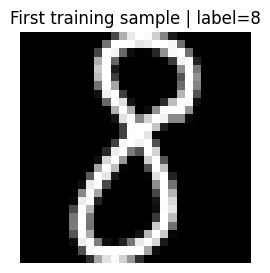

x_train[0,:,:] shape: (28, 28)


In [4]:
# ========== Show first training example ==========
i = 0
plt.figure(figsize=(3,3))
plt.imshow(x_train[i], cmap='gray')
plt.title(f"First training sample | label={y_train[i]}")
plt.axis("off")
plt.show()

# verify indexing like MNIST:
print("x_train[0,:,:] shape:", x_train[0,:,:].shape)

[8 5 7 4 4]


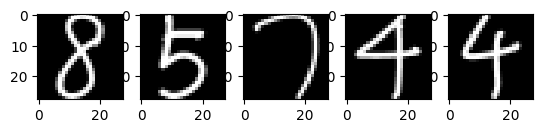

In [5]:
for i in range(0,5):					##  劃出數字
    plt.subplot(1, 5, i+1)
    img = x_train[i]
    plt.imshow(img, cmap="gray")

##cmap: ~matplotlib.colors.Colormap，可選，默認值： 無
##如果沒有，默認為 rc image.cmap 值。 如果 X 具有 RGB(A) 信息，則忽略 cmap


print(y_train[:5])  ## show 出前5筆 y

In [6]:
import numpy as np
# add channel  開始為 CNN 準備  矩陣要變成 (資料筆數, 長, 寬, 黑白=1/彩色=3)
x_train = np.expand_dims(x_train, axis=3)
x_test = np.expand_dims(x_test, axis=3)
## 手動將 mnist 的訓練資料依 80%/20% 的比例分做訓練及驗證資料
from sklearn.model_selection import train_test_split
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=25)

print(x_train.shape)
print(x_test.shape)
x_train_normalized = x_train / 255
x_val_normalized = x_val / 255
x_test_normalized = x_test / 255

(56, 28, 28, 1)
(30, 28, 28, 1)


In [9]:
import tensorflow.keras.utils as utils
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Flatten, Dropout, Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

y_train_onehot = utils.to_categorical(y_train)  ## 轉成 10個0/1 碼

def show_train_history(train_history, train, validation):
    plt.plot(train_history.history[train])
    plt.plot(train_history.history[validation])
    plt.title("Train History")
    plt.ylabel(train)
    plt.xlabel('Epoch')
    plt.show()


from keras.utils import *
from keras.models import Sequential
from keras.layers import Dense, Activation, Flatten, Dropout
from keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator



model = Sequential()
model.add(Conv2D(16, (5,5), activation="relu", padding="same", data_format="channels_last", input_shape=(28,28,1)))
model.add(MaxPooling2D(pool_size=(2,2), data_format="channels_last"))

model.add(Conv2D(36, (5,5), activation="relu", padding="same", data_format="channels_last"))
model.add(MaxPooling2D(pool_size=(2,2), data_format="channels_last"))

model.add(Flatten())
model.add(Dense(128, activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(10, activation="softmax"))

model.summary()






/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 16)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 36)     │        14,436 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 36)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1764)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       225,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,062 (945.55 KB)

 Trainable params: 242,062 (945.55 KB)

 Non-trainable params: 0 (0.00 B)

Saving 00.png to 00 (2).png
Saving 01.png to 01 (2).png
Saving 02.png to 02 (2).png
Saving 03.png to 03 (2).png
Saving 04.png to 04 (2).png
Saving 05.png to 05 (2).png
Saving 06.png to 06 (2).png
Saving 07.png to 07 (2).png
Saving 08.png to 08 (2).png
Saving 09.png to 09 (2).png
Saving 10.png to 10 (2).png
Saving 11.png to 11 (2).png
Saving 12.png to 12 (2).png
Saving 13.png to 13 (2).png
Saving 14.png to 14 (2).png
Saving 15.png to 15 (2).png
Saving 16.png to 16 (2).png
Saving 17.png to 17 (2).png
Saving 18.png to 18 (2).png
Saving 19.png to 19 (2).png
Saving 20.png to 20 (2).png
Saving 21.png to 21 (2).png
Saving 22.png to 22 (2).png
Saving 23.png to 23 (2).png
Saving 24.png to 24 (2).png
Saving 25.png to 25 (2).png
Saving 26.png to 26 (2).png
Saving 27.png to 27 (2).png
Saving 28.png to 28 (2).png
Saving 29.png to 29 (2).png
Saving 30.png to 30 (2).png
Saving 31.png to 31 (2).png
Saving 32.png to 32 (2).png
Saving 33.png to 33 (2).png
Saving 34.png to 34 (2).png
Saving 35.png to 35 

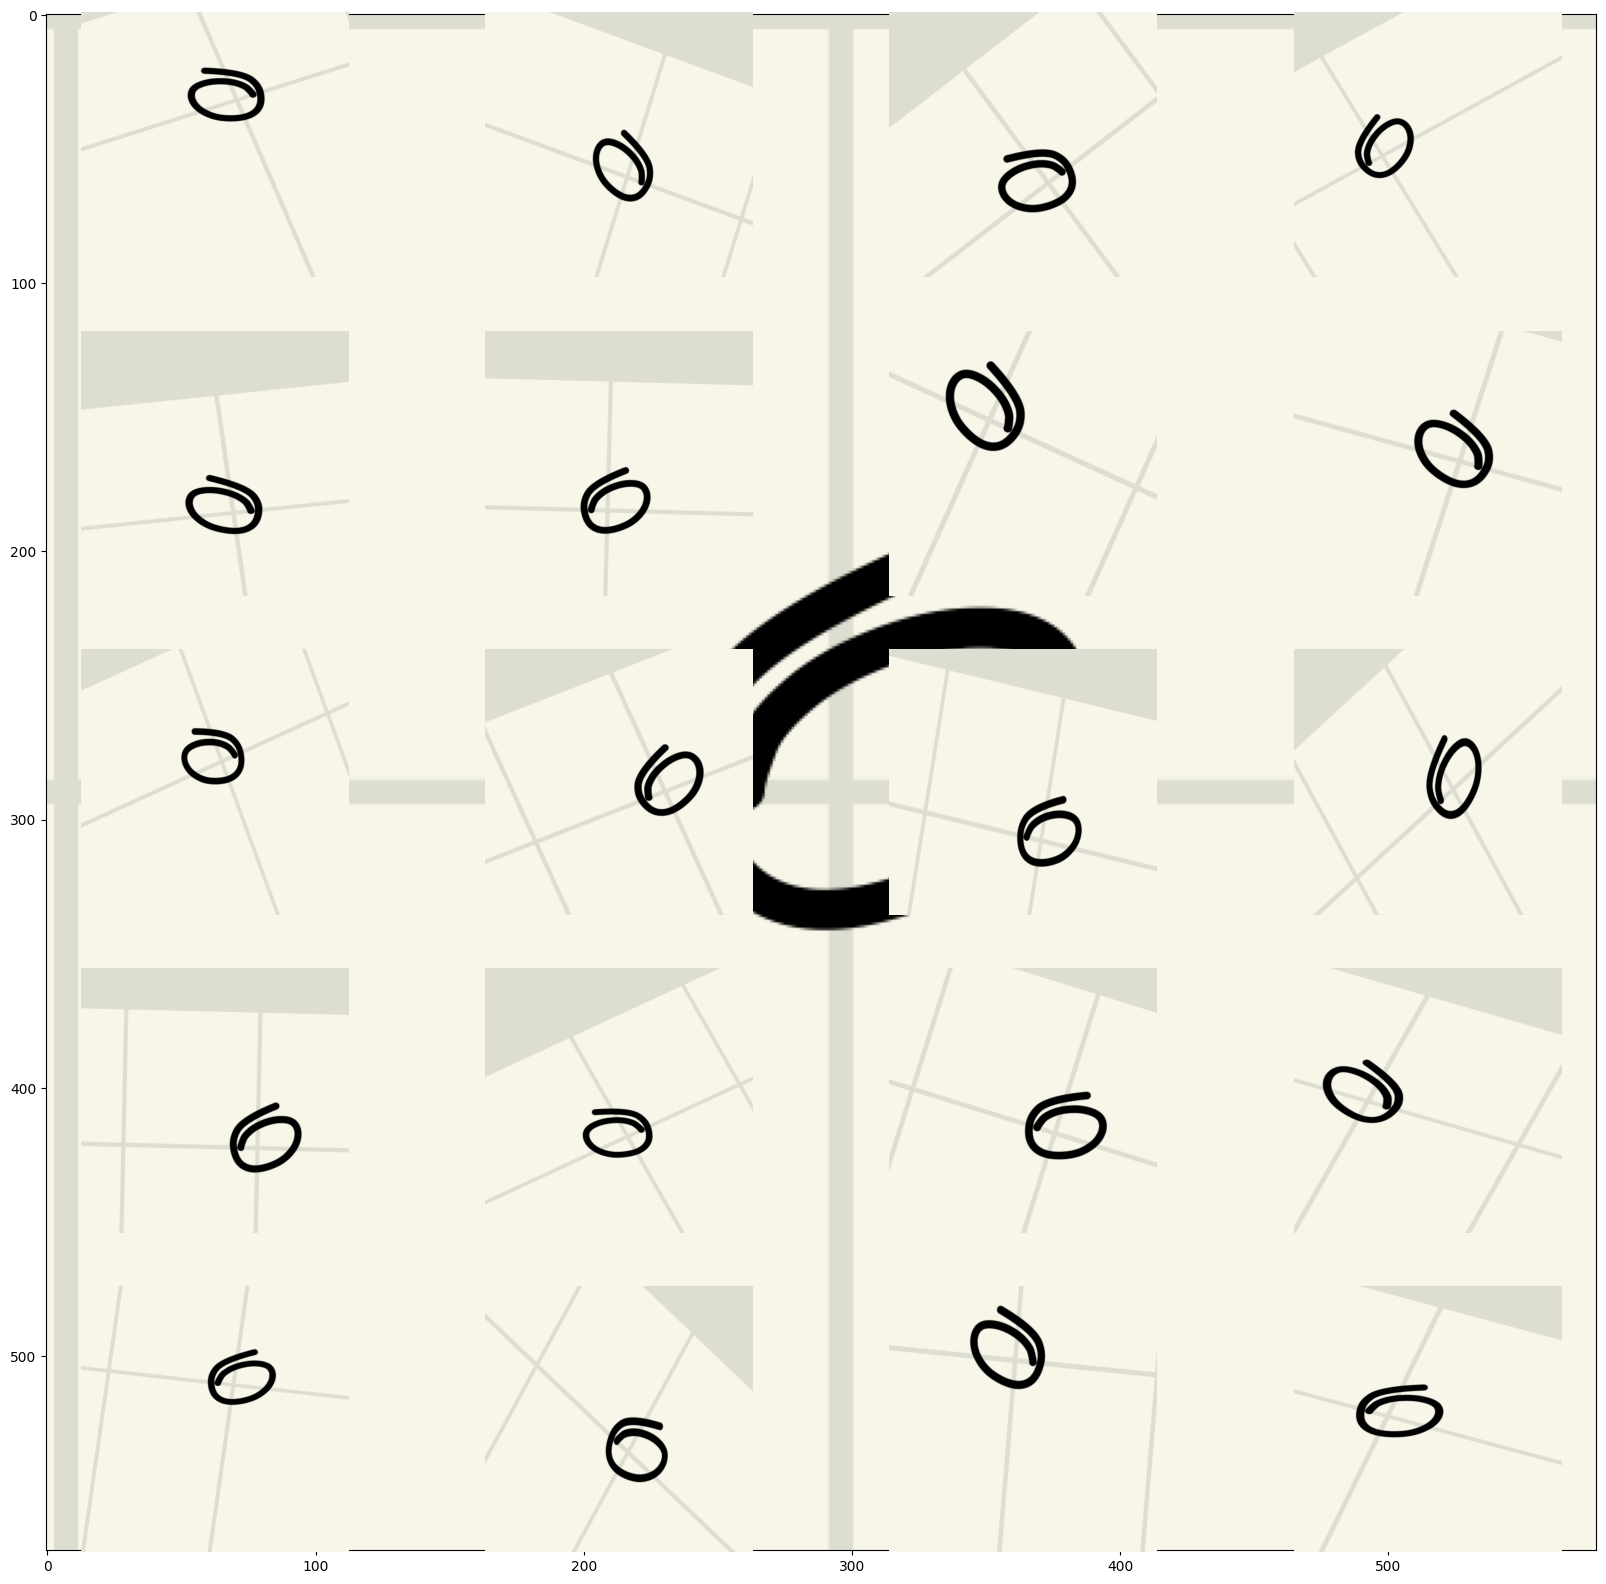

In [14]:
# coding: utf-8
# In[20]:
from matplotlib import pyplot as plt
import matplotlib.image as mpimg

import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import cv2
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.optimizers import RMSprop

# Plot inline
get_ipython().magic('matplotlib inline')
from pylab import rcParams
rcParams['figure.figsize'] = 20, 20


datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest')

## ! pip install pillow

from google.colab import files
uploaded = files.upload()
# use this after image in uploaded in the previous cell successfullt
img= image.load_img("00.png")
plt.imshow(img)


# In[21]:
x = img_to_array(img)  # this is a Numpy array with shape (3, 150, 150)
x = x.reshape((1,) + x.shape)  # this is a Numpy array with shape (1, 3, 150, 150)

# the .flow() command below generates batches of randomly transformed images
# and saves the results to the `preview/` directory
i = 0
for batch in datagen.flow(x, batch_size=1):
    plt.subplot(5,4,1 + i)
    plt.axis("off")

    augImage = batch[0]
    augImage = augImage.astype('float32')
    augImage /= 255
    plt.imshow(augImage)

    i += 1
    if i > 19:
        break  # otherwise the generator would loop indefinitely

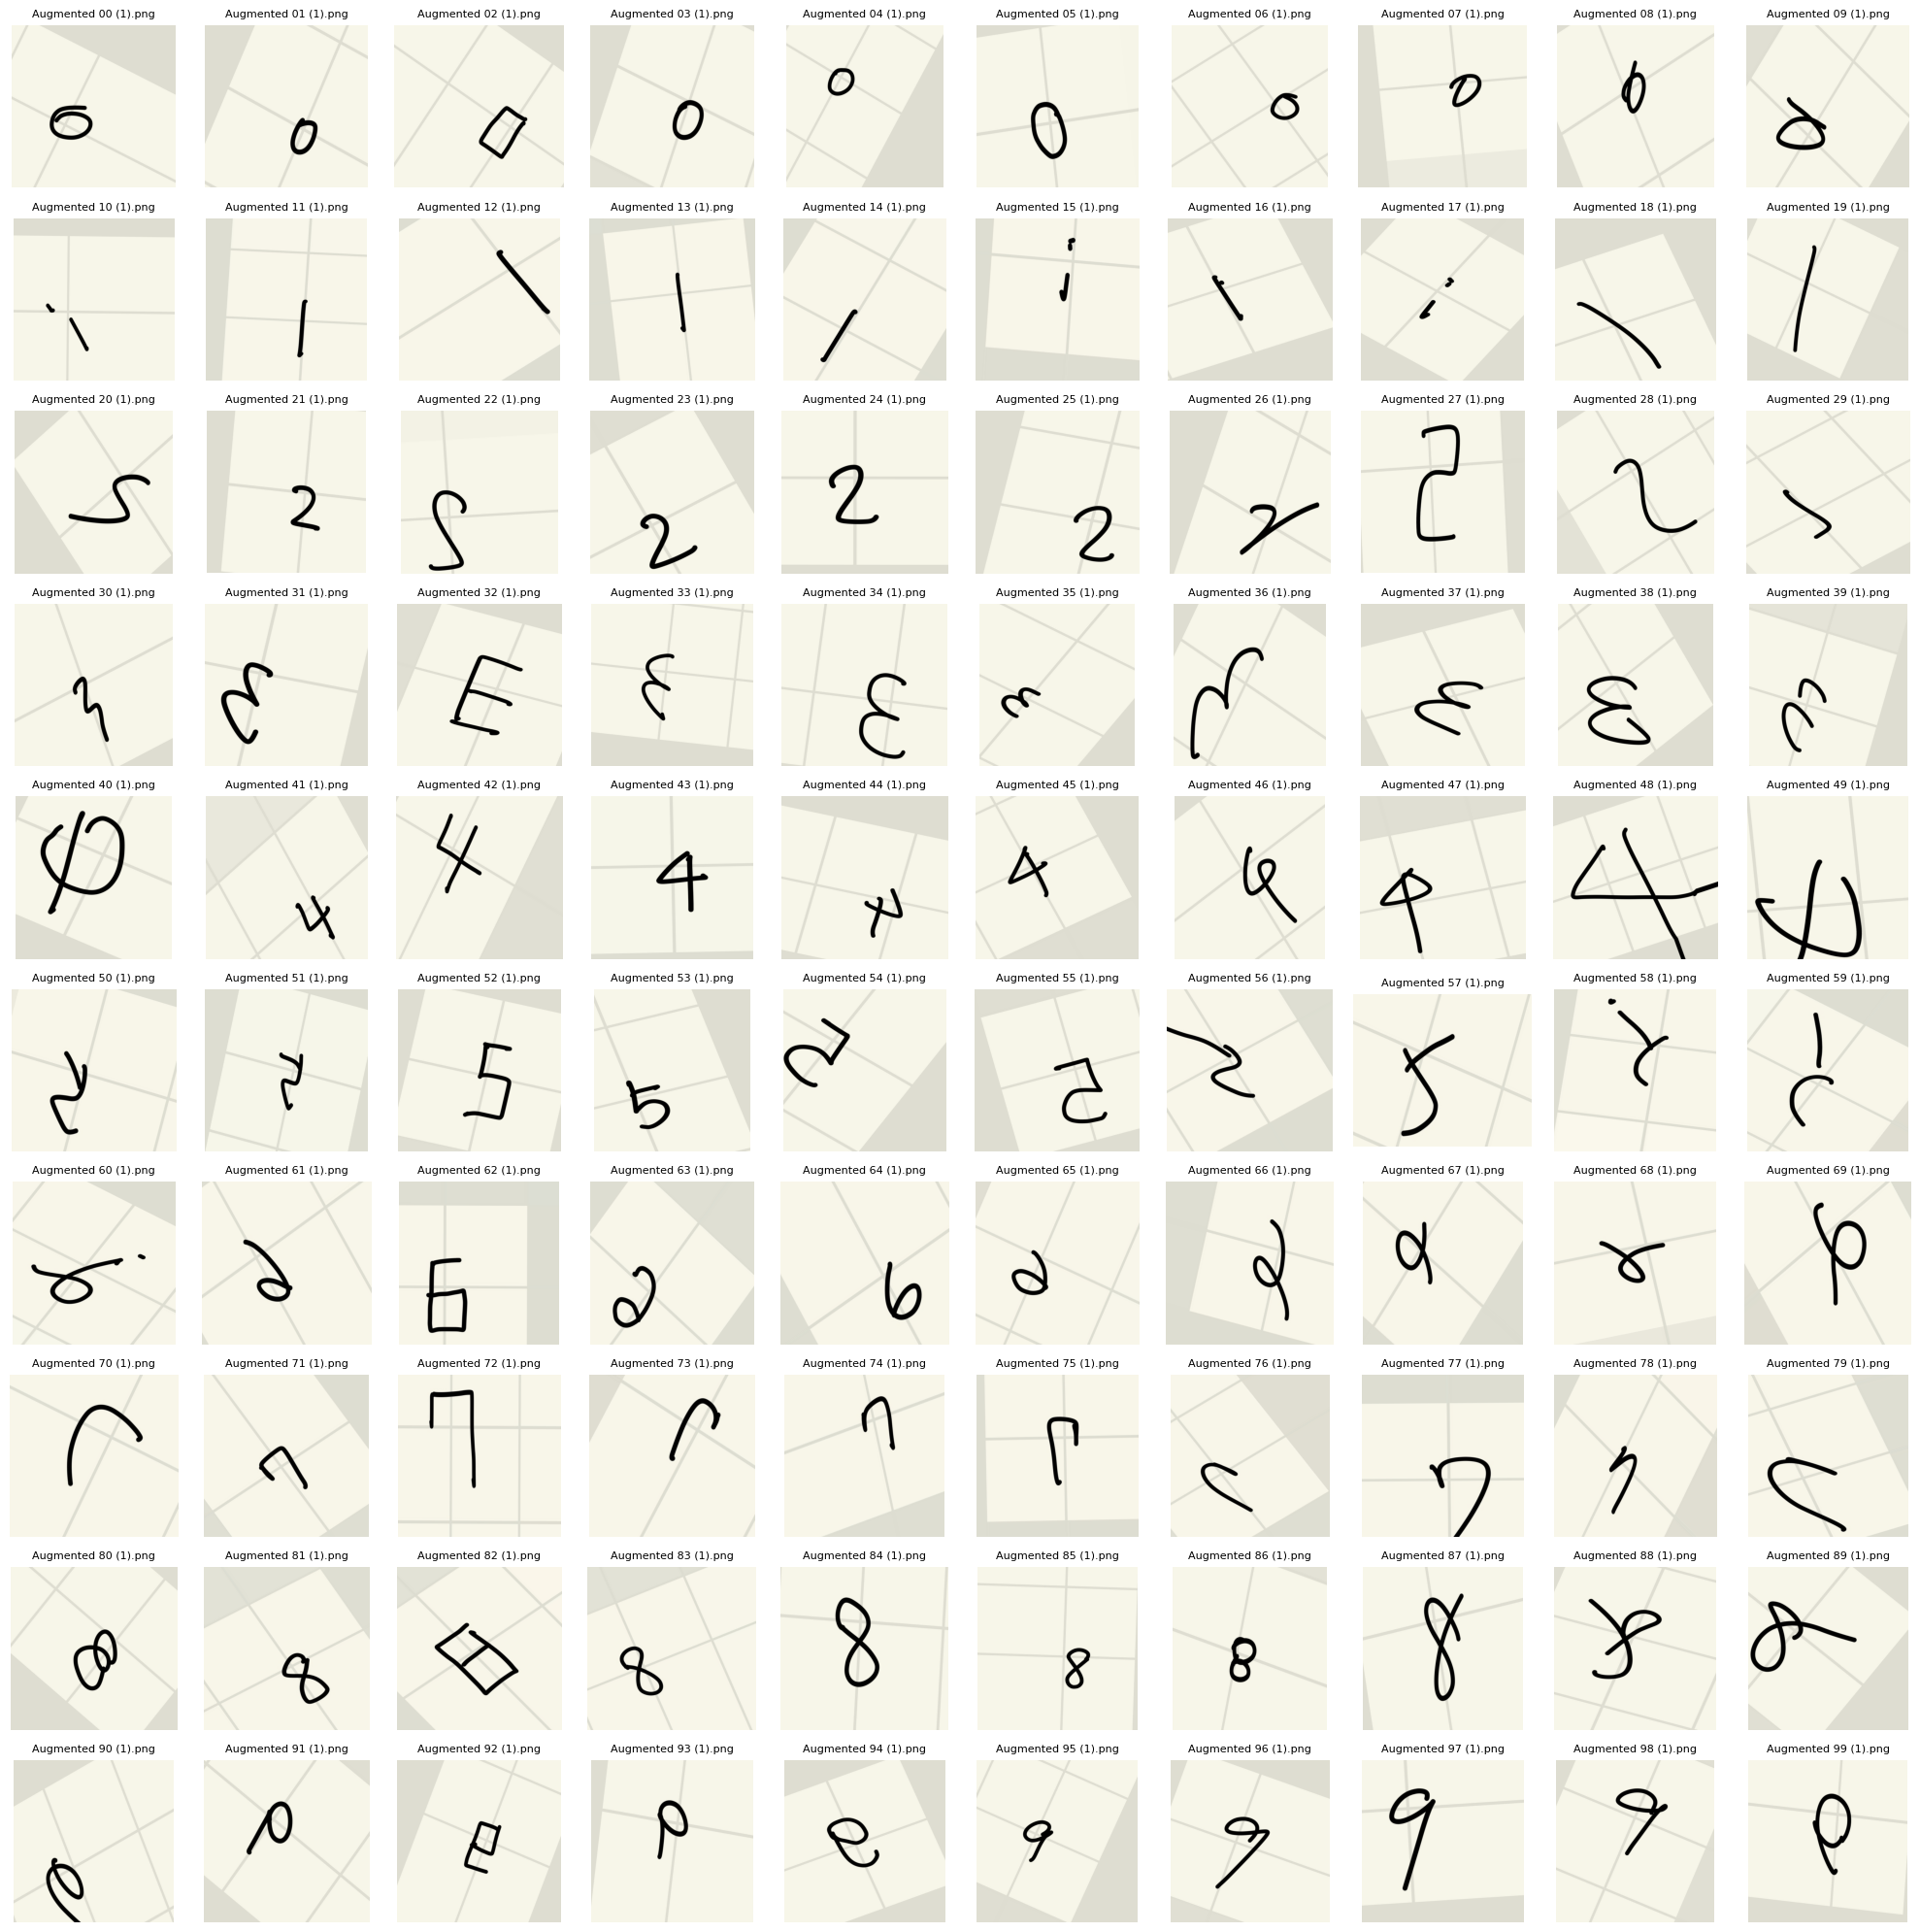

In [13]:
image_filenames_to_augment = sorted(list(uploaded.keys())) # 選擇所有已上傳的圖片來示範

plt.figure(figsize=(20, 20)) # 調整圖形大小以容納更多圖片

num_images = len(image_filenames_to_augment)
# 計算網格大小，例如 10x10
rows = int(np.ceil(np.sqrt(num_images)))
cols = int(np.ceil(num_images / rows))

for i, filename in enumerate(image_filenames_to_augment):
    if filename in uploaded: # 檢查檔案是否確實已上傳
        try:
            img = image.load_img(filename)
            x = image.img_to_array(img)
            x = x.reshape((1,) + x.shape)

            # 使用 datagen 產生一個增強後的圖片
            for batch in datagen.flow(x, batch_size=1):
                aug_image = batch[0]
                break # 只取一個增強後的版本

            plt.subplot(rows, cols, i + 1)
            plt.axis("off")
            plt.imshow(aug_image.astype('float32') / 255)
            plt.title(f"Augmented {filename}", fontsize=8)
        except Exception as e:
            print(f"處理檔案 {filename} 時發生錯誤: {e}")
    else:
        print(f"檔案 {filename} 未找到，請確認是否已上傳。")

plt.tight_layout()
plt.show()